# Imports

In [1]:
import os, gc, time, json, warnings
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly
from math import gcd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.backends.cudnn as cudnn
from torch.amp import autocast, GradScaler # Added for ultra-fast Mixed Precision Training

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
)

try:
    from thop import profile as thop_profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Enable cuDNN auto-tuner for hardware-level optimizations (faster training)
if torch.cuda.is_available():
    cudnn.benchmark = True

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU count       : {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'GPU {i}           : {torch.cuda.get_device_name(i)}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU count       : 2
GPU 0           : Tesla T4
GPU 1           : Tesla T4


# RAM Guard  *(25 GB hard cap — runs after every epoch)*

In [2]:
_PROC          = psutil.Process(os.getpid())
RAM_HARD_LIMIT = 25.0
RAM_WARN_AT    = 22.0

def _ram_gb() -> float:
    return _PROC.memory_info().rss / (1024 ** 3)

def _gpu_summary() -> str:
    """One-line GPU memory string mapping all available GPUs."""
    if not torch.cuda.is_available():
        return ''
    
    summary = []
    for i in range(torch.cuda.device_count()):
        # Calculate used and reserved VRAM in GB
        gb_used = torch.cuda.memory_allocated(i) / 1e9
        gb_res  = torch.cuda.memory_reserved(i) / 1e9
        summary.append(f'GPU{i}: {gb_used:.2f}/{gb_res:.2f} GB')
        
    return '  |  ' + ' | '.join(summary)

def ram_guard(label: str = '', force: bool = False) -> float:
    # Clear CPU memory
    gc.collect()
    
    # Clear PyTorch's unused cached GPU memory to prevent OOM
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    used = _ram_gb()
    
    if force or used >= RAM_WARN_AT:
        tag = f'[RAM] {label:<30s}' if label else '[RAM]'
        print(f'  {tag}  {used:.2f} GB{_gpu_summary()}')
        
    if used > RAM_HARD_LIMIT:
        raise MemoryError(
            f'RAM hard limit breached: {used:.2f} GB > {RAM_HARD_LIMIT} GB  '
            f'(at: {label})'
        )
    return used

# Configuration — TPU v5e-8 (8 cores)

In [3]:
import random, torch
from pathlib import Path

class Config:
    # ── Paths ──────────────────────────────────────────────────────────────
    KAGGLE_INPUT   = Path('/kaggle/input/datasets/rayaanraza1/ninapro-db7/Dataset')
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_LOSO5'
    CACHE_DIR      = KAGGLE_WORKING / 'cache_LOSO5'
    PLOT_DIR       = KAGGLE_WORKING / 'plots_LOSO5'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_LOSO5'

    # ── Subjects ───────────────────────────────────────────────────────────
    SUBJECTS       = list(range(1, 6))    # 1 … 5
    EMG_FS         = 2000
    ACC_FS         = 148
    TARGET_FS      = 2000

    EMG_KEY            = 'emg'
    ACC_KEY            = 'acc'
    LBL_KEY            = 'restimulus'
    GESTURE_REST_LABEL = 0

    # ── Windowing ──────────────────────────────────────────────────────────
    WIN_MS       = 200
    STEP_MS      = 100
    WIN_SAMPLES  = int(WIN_MS  * TARGET_FS / 1000)   # 400 samples
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)   # 200 samples

    # ── Training ───────────────────────────────────────────────────────────
    VAL_FRAC             = 0.10
    NORM_SAMPLE_PER_SUBJ = 2_000
    MIN_EPOCHS           = 50
    MAX_EPOCHS           = 80
    PATIENCE             = 20
    
    # ── Dual GPU Configuration ─────────────────────────────────────────────
    N_GPUS       = torch.cuda.device_count()
    BASE_BATCH   = 256
    # Effective global batch size scales with available GPUs
    BATCH_SIZE   = BASE_BATCH * max(1, N_GPUS) 
    LR           = 1e-3
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 4
    SEED         = 42

    # ── RAM guard ──────────────────────────────────────────────────────────
    RAM_LOG_EVERY_N_EPOCHS = 5

    # ── Device ─────────────────────────────────────────────────────────────
    DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reproducibility ────────────────────────────────────────────────────────
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)

for d in [Config.CKPT_DIR, Config.CACHE_DIR, Config.PLOT_DIR, Config.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Device           : {Config.DEVICE}')
print(f'GPUs Available   : {Config.N_GPUS}')
print(f'Global batch     : {Config.BATCH_SIZE}')
print(f'Subjects         : {len(Config.SUBJECTS)}  |  Strategy: {len(Config.SUBJECTS)}-fold LOSO')
print(f'Win              : {Config.WIN_SAMPLES} samples ({Config.WIN_MS} ms)  '
      f'Step: {Config.STEP_SAMPLES} samples ({Config.STEP_MS} ms)')
ram_guard(label='startup', force=True)

Device           : cuda
GPUs Available   : 2
Global batch     : 512
Subjects         : 5  |  Strategy: 5-fold LOSO
Win              : 400 samples (200 ms)  Step: 200 samples (100 ms)
  [RAM] startup                         0.71 GB  |  GPU0: 0.00/0.00 GB | GPU1: 0.00/0.00 GB


0.7096443176269531

# EMG + ACC Preprocessor

In [4]:
class EMGAccPreprocessor:
    """Loads one .mat file, resamples ACC to EMG rate, strips rest frames."""

    def _find_key(self, data, candidates):
        # Optimization: Map all keys to lowercase once for instant O(1) lookups
        data_keys_lower = {k.lower(): k for k in data.keys()}
        for c in candidates:
            if c.lower() in data_keys_lower:
                return data_keys_lower[c.lower()]
        return None

    def apply(self, mat_path: Path):
        data    = io.loadmat(str(mat_path))
        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY, 'glove'])
        lbl_key = self._find_key(data, [Config.LBL_KEY, 'stimulus', 'label', 'labels'])

        if not emg_key: raise KeyError(f'No EMG key in {mat_path.name}')
        if not lbl_key: raise KeyError(f'No label key in {mat_path.name}')

        # Force float32 immediately to ensure perfect VRAM compatibility later
        emg    = data[emg_key].astype(np.float32)
        labels = data[lbl_key].flatten().astype(np.int32)
        n_emg  = len(emg)

        if acc_key is not None:
            acc   = data[acc_key].astype(np.float32)
            n_acc = len(acc)
            
            if n_acc != n_emg:
                up   = round((n_emg / n_acc) * Config.ACC_FS)
                down = Config.ACC_FS
                g    = gcd(up, down)
                acc  = resample_poly(acc, up // g, down // g, axis=0).astype(np.float32)
            
            # Match lengths exactly
            curr_acc_len = len(acc)
            if curr_acc_len > n_emg:
                acc = acc[:n_emg]
            elif curr_acc_len < n_emg:
                # np.pad is significantly faster and more memory-efficient than np.vstack
                acc = np.pad(acc, ((0, n_emg - curr_acc_len), (0, 0)), mode='constant')
        else:
            acc = np.zeros((n_emg, 0), dtype=np.float32)

        # Truncate to shortest length to avoid index out-of-bounds
        n = min(n_emg, len(labels))
        
        # Fast boolean indexing
        mask = labels[:n] > Config.GESTURE_REST_LABEL
        
        return emg[:n][mask], acc[:n][mask], labels[:n][mask]

# Subject Loader  (float16 cache + mmap)

In [5]:
from numpy.lib.stride_tricks import sliding_window_view

class SubjectLoader:
    def __init__(self):
        self.pre = EMGAccPreprocessor()

    def _Xpath(self, sid): return Config.CACHE_DIR / f's{sid:02d}_X.npy'
    def _ypath(self, sid): return Config.CACHE_DIR / f's{sid:02d}_y.npy'
    def _meta (self, sid): return Config.CACHE_DIR / f's{sid:02d}_meta.json'

    def _find_dir(self, sid):
        for name in [f'Subject_{sid}', f'subject_{sid}',
                     f'S{sid:02d}', f'S{sid}', f's{sid}']:
            p = Config.KAGGLE_INPUT / name
            if p.is_dir(): return p
        raise FileNotFoundError(f'Cannot locate folder for subject {sid}')

    def _scan_acc_channels(self, subjects):
        max_acc = 0
        for sid in subjects:
            try:
                subj_dir = self._find_dir(sid)
                for mf in sorted(subj_dir.glob('*.mat')):
                    try:
                        _, acc, _ = self.pre.apply(mf)
                        max_acc = max(max_acc, acc.shape[1])
                    except Exception:
                        pass
            except Exception:
                pass
        return max_acc

    def _cache_one(self, sid, n_acc_global):
        subj_dir  = self._find_dir(sid)
        mat_files = sorted(subj_dir.glob('*.mat'))
        if not mat_files:
            mat_files = sorted(subj_dir.rglob('*.mat'))

        emg_parts, acc_parts, lbl_parts = [], [], []
        for mf in mat_files:
            try:
                e, a, l = self.pre.apply(mf)
                if a.shape[1] < n_acc_global:
                    # Optimization: np.pad is faster and uses less memory
                    a = np.pad(a, ((0, 0), (0, n_acc_global - a.shape[1])), mode='constant')
                emg_parts.append(e)
                acc_parts.append(a)
                lbl_parts.append(l)
            except Exception as ex:
                print(f'    skip {mf.name}: {ex}')

        if not emg_parts:
            raise RuntimeError(f'No valid data for S{sid:02d}')

        # Optimization: np.concatenate is highly optimized in C under the hood
        emg = np.concatenate(emg_parts, axis=0)
        acc = np.concatenate(acc_parts, axis=0) if n_acc_global > 0 else np.zeros(
            (len(emg), 0), dtype=np.float32)
        lbl = np.concatenate(lbl_parts, axis=0)

        sig  = np.concatenate([emg, acc], axis=1) if acc.shape[1] > 0 else emg
        n_ch = sig.shape[1]
        W, S = Config.WIN_SAMPLES, Config.STEP_SAMPLES

        # Free raw arrays early before creating views
        del emg_parts, acc_parts, lbl_parts, emg, acc
        gc.collect()

        # ── Vectorized Windowing Strategy (Zero-Copy Views) ─────────────────
        # This replaces the slow 'for' loop and array appending.
        sig_view = sliding_window_view(sig, window_shape=W, axis=0)[::S] 
        lbl_view = sliding_window_view(lbl, window_shape=W, axis=0)[::S] 

        # Fast comprehension for label majority vote
        y_all = np.array([np.bincount(w).argmax() for w in lbl_view], dtype=np.int16)
        
        # Boolean masking instantly filters out rest frames
        valid_mask = y_all != Config.GESTURE_REST_LABEL
        
        # We only allocate physical memory here at the very end
        X = sig_view[valid_mask].astype(np.float16)
        y = y_all[valid_mask]
        # ──────────────────────────────────────────────────────────────────────

        del sig_view, lbl_view, y_all, valid_mask, sig, lbl
        gc.collect()

        np.save(str(self._Xpath(sid)), X)
        np.save(str(self._ypath(sid)), y)
        self._meta(sid).write_text(json.dumps({
            'n_channels': n_ch, 'n_windows': len(y),
            'n_acc_ch'  : n_acc_global,
            'unique_labels': sorted(set(y.tolist()))
        }))
        
        del X, y
        gc.collect()
        return n_ch

    def process_all(self, subjects=None):
        subjects  = subjects or Config.SUBJECTS
        available = []

        uncached = [s for s in subjects if not self._meta(s).exists()]
        if uncached:
            print('Scanning ACC channels across subjects …')
            n_acc_global = self._scan_acc_channels(uncached)
            for s in subjects:
                if self._meta(s).exists():
                    m = json.loads(self._meta(s).read_text())
                    n_acc_global = max(n_acc_global, m['n_acc_ch'])
            print(f'  → Global ACC channels: {n_acc_global}')
        else:
            meta0        = json.loads(self._meta(subjects[0]).read_text())
            n_acc_global = meta0['n_acc_ch']

        n_ch = None
        for sid in tqdm(subjects, desc='Caching subjects'):
            if self._meta(sid).exists():
                m    = json.loads(self._meta(sid).read_text())
                n_ch = m['n_channels']
                available.append(sid)
                print(f'  S{sid:02d}: cache hit  ({m["n_windows"]:,} windows)')
                continue
            try:
                n_ch = self._cache_one(sid, n_acc_global)
                m    = json.loads(self._meta(sid).read_text())
                available.append(sid)
                print(f'  S{sid:02d}: cached     ({m["n_windows"]:,} windows | '
                      f'labels {m["unique_labels"]})')
            except Exception as ex:
                print(f'  S{sid:02d}: FAILED — {ex}')
            ram_guard(label=f'after caching S{sid:02d}')

        return available, (n_ch or 0)

# Memory-Mapped Subject Dataset

In [6]:
class MemmapSubjectDataset(Dataset):
    """
    Reads one subject's cached .npy files via memory-mapping.
    Returns CPU tensors. Use DataLoader with pin_memory=True for fast async GPU transfer.
    """

    def __init__(self, sid: int, normalizer=None):
        self.X    = np.load(str(Config.CACHE_DIR / f's{sid:02d}_X.npy'), mmap_mode='r')
        self.y    = np.load(str(Config.CACHE_DIR / f's{sid:02d}_y.npy'), mmap_mode='r')
        self.norm = normalizer

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].astype(np.float32)
        if self.norm is not None:
            x = (x - self.norm.mean[0]) / self.norm.std[0]
        return torch.from_numpy(x), int(self.y[idx])

# Channel Normaliser  (incremental, no full-RAM load)

In [7]:
class ChannelNormalizer:
    """Channel-wise z-score normaliser; samples via mmap — no full RAM load."""

    def __init__(self):
        self.mean = None   # (1, C, 1) float32
        self.std  = None
        # Modern, lightning-fast random generator for CPU sampling
        self.rng  = np.random.default_rng(Config.SEED)

    def fit_from_subjects(self, train_sids: list):
        samples = []
        per_subj = Config.NORM_SAMPLE_PER_SUBJ

        for sid in train_sids:
            X_mm = np.load(str(Config.CACHE_DIR / f's{sid:02d}_X.npy'), mmap_mode='r')
            n    = len(X_mm)
            
            # Optimized sampling: faster execution and strict reproducibility
            idx  = np.sort(self.rng.choice(n, min(n, per_subj), replace=False))
            samples.append(X_mm[idx].astype(np.float32))
            
            del X_mm

        X_sample  = np.concatenate(samples, axis=0)
        self.mean = X_sample.mean(axis=(0, 2), keepdims=True)
        self.std  = X_sample.std (axis=(0, 2), keepdims=True) + 1e-8
        
        del X_sample, samples
        gc.collect()
        return self

    def fit(self, X):
        self.mean = X.mean(axis=(0, 2), keepdims=True)
        self.std  = X.std (axis=(0, 2), keepdims=True) + 1e-8
        return self

    def transform(self, X):
        return (X - self.mean) / self.std

# DataLoader Factory  (TPU-aware with XLA ParallelLoader)

In [8]:
def make_loaders(train_sids, test_sid, normalizer, n_classes):
    """
    Build CPU DataLoaders for one LOSO fold.
    Optimized for Dual GPU with pin_memory=True for lightning-fast host-to-device transfers.
    """
    train_ds = ConcatDataset([
        MemmapSubjectDataset(sid, normalizer) for sid in train_sids
    ])

    n_train = len(train_ds)
    n_val   = max(1, int(n_train * Config.VAL_FRAC))
    
    rng = np.random.default_rng(Config.SEED)
    val_idx = np.sort(rng.choice(n_train, n_val, replace=False))
    train_idx = np.setdiff1d(np.arange(n_train), val_idx)

    from torch.utils.data import Subset
    tr_ds  = Subset(train_ds, train_idx)
    val_ds = Subset(train_ds, val_idx)
    tst_ds = MemmapSubjectDataset(test_sid, normalizer)

    kw = dict(
        num_workers        = Config.NUM_WORKERS,
        pin_memory         = torch.cuda.is_available(), # Crucial for Multi-GPU speed
        persistent_workers = (Config.NUM_WORKERS > 0),
        prefetch_factor    = 2 if Config.NUM_WORKERS > 0 else None,
        drop_last          = False, 
    )

    tr_loader  = DataLoader(tr_ds,  batch_size=Config.BATCH_SIZE, shuffle=True,  **kw)
    val_loader = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False, **kw)
    tst_loader = DataLoader(tst_ds, batch_size=Config.BATCH_SIZE, shuffle=False, **kw)

    print(f'  DataLoaders — train {len(tr_ds):,}  val {len(val_ds):,}  '
          f'test {len(tst_ds):,}  global batch {Config.BATCH_SIZE}  workers {Config.NUM_WORKERS}')
    return tr_loader, val_loader, tst_loader

# Multi-Kernel Attention 1D CNN  +  TPU helper

In [9]:
# ── Building blocks ────────────────────────────────────────────────────────
class _ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv1d(in_ch, out_ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
        ]
        if pool: layers.append(nn.MaxPool1d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class _AttentionBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(ch, ch//4, 1), nn.ReLU(inplace=True),
            nn.Conv1d(ch//4, ch, 1), nn.Sigmoid(),
        )
    def forward(self, x): return x * self.se(x)

class MultiKernelAttention1DCNN(nn.Module):
    def __init__(self, n_channels: int, n_classes: int, dropout: float = 0.3):
        super().__init__()
        self.n_channels = n_channels
        self.features   = nn.Sequential(
            _ConvBlock(n_channels, 64,  kernel=7, pool=True),  _AttentionBlock(64),
            _ConvBlock(64,        128,  kernel=5, pool=True),  _AttentionBlock(128),
            _ConvBlock(128,       256,  kernel=3, pool=False),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.head(self.pool(self.features(x)).squeeze(-1))
    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def build_model(n_channels, n_classes):
    """
    Constructs the model and dynamically wraps it in nn.DataParallel 
    to instantly distribute processing across all available GPUs.
    """
    model = MultiKernelAttention1DCNN(n_channels, n_classes).to(Config.DEVICE)
    
    if Config.N_GPUS > 1:
        model = nn.DataParallel(model)
        
    print(f'  Model on {Config.DEVICE}  '
          f'(GPUs={Config.N_GPUS}, params={unwrap(model).count_params():,})')
    return model


def unwrap(model):
    """Safely extracts the core model from DataParallel wrapper for checkpoint saving."""
    return model.module if isinstance(model, nn.DataParallel) else model


def compute_gflops(n_channels):
    if not HAS_THOP: return -1.0
    m     = MultiKernelAttention1DCNN(n_channels, 2)
    dummy = torch.zeros(1, n_channels, Config.WIN_SAMPLES)
    macs, _ = thop_profile(m, inputs=(dummy,), verbose=False)
    return macs * 2 / 1e9

# Trainer  (TPU v5e-8 — XLA ParallelLoader + xm.optimizer_step)

In [10]:
class Trainer:
    """
    Trains MultiKernelAttention1DCNN distributed seamlessly across Dual GPUs.
    Optimized with Automatic Mixed Precision (AMP) for lightning-fast training.
    """

    def __init__(self, model, save_path: Path, fold_tag: str = ''):
        self.model     = model
        self.save_path = save_path
        self.fold_tag  = fold_tag
        self.history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
        # Initialize AMP Scaler for mixed precision training
        self.scaler    = GradScaler('cuda') if torch.cuda.is_available() else None

    # ── Single epoch using native CUDA optimization ───────────────────────
    def _epoch(self, loader, opt=None, crit=None):
        training = opt is not None
        self.model.train(training)
        loss_sum = correct = total = 0

        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for X, y in loader:
                # non_blocking=True utilizes pinned memory for asynchronous GPU transfer
                X = X.to(Config.DEVICE, non_blocking=True)
                y = y.to(Config.DEVICE, non_blocking=True)
                
                # Automatic Mixed Precision context for maximum throughput
                with autocast('cuda', enabled=training and self.scaler is not None):
                    out  = self.model(X)
                    loss = crit(out, y)
                
                if training:
                    opt.zero_grad()
                    self.scaler.scale(loss).backward()
                    self.scaler.step(opt)
                    self.scaler.update()
                
                loss_sum += loss.item() * len(y)
                correct  += (out.argmax(1) == y).sum().item()
                total    += len(y)
                del X, y, out, loss

        return loss_sum / max(total, 1), correct / max(total, 1)

    # ── Full training loop ────────────────────────────────────────────────
    def fit(self, tr_loader, val_loader):
        opt   = Adam(self.model.parameters(),
                     lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
        crit  = nn.CrossEntropyLoss()
        sched = CosineAnnealingLR(opt, T_max=Config.MAX_EPOCHS)
        best  = float('inf')
        pat   = 0
        t0    = time.perf_counter()

        for ep in range(1, Config.MAX_EPOCHS + 1):

            tl, ta = self._epoch(tr_loader, opt, crit)
            vl, va = self._epoch(val_loader, crit=crit)
            sched.step()

            self.history['train_loss'].append(tl)
            self.history['val_loss'  ].append(vl)
            self.history['train_acc' ].append(ta)
            self.history['val_acc'   ].append(va)

            if vl < best:
                best = vl
                pat  = 0
                torch.save(unwrap(self.model).state_dict(), str(self.save_path))
            else:
                pat += 1

            if ep % 10 == 0:
                print(f'  ep {ep:3d}  tl={tl:.4f} ta={ta:.4f}  '
                      f'vl={vl:.4f} va={va:.4f}')

            # Per-epoch RAM/VRAM flush
            log_this = (ep % Config.RAM_LOG_EVERY_N_EPOCHS == 0)
            ram_guard(
                label=f'{self.fold_tag}  ep={ep:3d}',
                force=log_this
            )

            if ep >= Config.MIN_EPOCHS and pat >= Config.PATIENCE:
                print(f'  Early stop at ep {ep}  (best val_loss={best:.4f})')
                break

        self.wall = time.perf_counter() - t0
        print(f'  Wall: {self.wall:.1f}s  Best val_loss: {best:.4f}')
        return self

# Evaluator

In [11]:
class Evaluator:
    def __init__(self, save_path, n_channels, n_classes, class_names):
        self.save_path   = save_path
        self.n_channels  = n_channels
        self.n_classes   = n_classes
        self.class_names = class_names

    def _load(self):
        m = MultiKernelAttention1DCNN(self.n_channels, self.n_classes)
        # Load weights directly to the appropriate device
        m.load_state_dict(torch.load(str(self.save_path), map_location=Config.DEVICE))
        m = m.to(Config.DEVICE)
        
        # Re-wrap in DataParallel for multi-GPU inference
        if Config.N_GPUS > 1:
            m = nn.DataParallel(m)
            
        return m.eval()

    def run(self, loader, tag):
        model = self._load()
        preds, probas, trues = [], [], []
        t0 = time.perf_counter()

        with torch.no_grad():
            for X, y in loader:
                # Fast async host-to-device transfers
                X = X.to(Config.DEVICE, non_blocking=True)
                y = y.to(Config.DEVICE, non_blocking=True)
                
                # Mixed precision inference for maximum speed
                with autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(X)
                    
                probas.append(torch.softmax(logits, 1).cpu().numpy())
                preds .append(logits.argmax(1).cpu().numpy())
                trues .append(y.cpu().numpy())
                del X, y, logits

        wall = time.perf_counter() - t0
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        probas = np.vstack(probas)
        preds  = np.concatenate(preds)
        trues  = np.concatenate(trues)

        per_cls = {}
        for c in range(self.n_classes):
            m = trues == c
            if m.sum(): per_cls[self.class_names[c]] = float(accuracy_score(trues[m], preds[m]))

        try:
            auc = roc_auc_score(trues, probas, multi_class='ovr',
                                average='weighted', labels=list(range(self.n_classes)))
        except Exception:
            auc = float('nan')

        metrics = dict(
            split         = tag,
            accuracy      = accuracy_score(trues, preds),
            precision_w   = precision_score(trues, preds, average='weighted', zero_division=0),
            recall_w      = recall_score   (trues, preds, average='weighted', zero_division=0),
            f1_w          = f1_score       (trues, preds, average='weighted', zero_division=0),
            roc_auc_w     = auc,
            per_class_acc = per_cls,
            test_wall_s   = wall,
            test_samples  = len(trues),
        )
        t = tag.replace(':','_').replace(' ','_')
        self._cm (trues, preds,  tag, t)
        self._roc(trues, probas, tag, t)
        return metrics, trues, probas

    def _cm(self, yt, yp, title, tag):
        cm  = confusion_matrix(yt, yp, labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(1, keepdims=True) + 1e-8)
        fig, axs = plt.subplots(1,2, figsize=(18,7))
        for ax, mat, lbl in zip(axs, [cm,cmn], ['Count','Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues',
                        xticklabels=self.class_names, yticklabels=self.class_names,
                        annot=(self.n_classes<=17),
                        fmt=('.2f' if lbl=='Normalised' else 'd'), linewidths=.3)
            ax.set_title(f'CM ({lbl}) — {title}', fontsize=10)
            ax.set_xlabel('Predicted'); ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=7)
        plt.tight_layout()
        plt.savefig(Config.PLOT_DIR/f'cm_{tag}.png', dpi=100, bbox_inches='tight')
        plt.show(); plt.close('all')

    def _roc(self, yt, yp, title, tag):
        fig, ax = plt.subplots(figsize=(9,7))
        cols = plt.cm.tab20(np.linspace(0,1,self.n_classes))
        for c in range(self.n_classes):
            if (yt==c).sum()==0: continue
            fpr,tpr,_ = roc_curve((yt==c).astype(int), yp[:,c])
            try:   a = roc_auc_score((yt==c).astype(int), yp[:,c])
            except: a = float('nan')
            ax.plot(fpr, tpr, color=cols[c], lw=1.1,
                    label=f'{self.class_names[c]} ({a:.2f})')
        ax.plot([0,1],[0,1],'k--',lw=.8)
        ax.set_title(f'ROC — {title}'); ax.legend(fontsize=6, ncol=2)
        plt.tight_layout()
        plt.savefig(Config.PLOT_DIR/f'roc_{tag}.png', dpi=100, bbox_inches='tight')
        plt.show(); plt.close('all')

# Learning Curve Plotter

In [12]:
def plot_curves(history, tag):
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    ep = range(1, len(history['train_loss']) + 1)
    
    axs[0].plot(ep, history['train_loss'], label='train')
    axs[0].plot(ep, history['val_loss'],   label='val')
    axs[0].set_title(f'Loss — {tag}')
    axs[0].legend()
    
    axs[1].plot(ep, history['train_acc'], label='train')
    axs[1].plot(ep, history['val_acc'],   label='val')
    axs[1].set_title(f'Accuracy — {tag}')
    axs[1].legend()
    
    plt.tight_layout()
    t = tag.replace(':', '_').replace(' ', '_')
    plt.savefig(Config.PLOT_DIR / f'curves_{t}.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close('all')

# LOSO Fold Runner

In [13]:
def run_loso_fold(fold_idx, test_sid, train_sids,
                  n_channels, n_classes, class_names):
    """Run one LOSO fold end-to-end with full RAM/VRAM management on Dual GPU."""
    tag = f'LOSO_fold{fold_idx+1:02d}_testS{test_sid:02d}'
    print(f"\n{'='*72}")
    print(f'  Fold {fold_idx+1:02d}/{len(Config.SUBJECTS)}  '
          f'— test: Subject {test_sid:02d}  '
          f'| train: {len(train_sids)} subjects')
    print(f"{'='*72}")

    ram_guard(label=f'pre-fold {fold_idx+1}', force=True)

    print('  Fitting normaliser …')
    norm = ChannelNormalizer().fit_from_subjects(train_sids)
    ram_guard(label='after normaliser')

    tr_loader, val_loader, tst_loader = make_loaders(
        train_sids, test_sid, norm, n_classes)

    model     = build_model(n_channels, n_classes)
    save_path = Config.CKPT_DIR / f'{tag}.pt'
    gflops    = compute_gflops(n_channels)

    trainer = Trainer(model, save_path, fold_tag=tag)
    trainer.fit(tr_loader, val_loader)
    plot_curves(trainer.history, tag)

    ev = Evaluator(save_path, n_channels, n_classes, class_names)
    metrics, y_true, y_proba = ev.run(tst_loader, tag)

    metrics.update(
        train_wall_s      = trainer.wall,
        gflops_per_window = gflops,
        n_params          = unwrap(model).count_params(),
        epochs_trained    = len(trainer.history['train_loss']),
        train_size        = len(tr_loader.dataset),
        val_size          = len(val_loader.dataset),
        test_size         = len(tst_loader.dataset),
        test_subject      = test_sid,
        n_gpus            = Config.N_GPUS, # Updated for Dual GPU setup
    )

    print(f'  acc={metrics["accuracy"]:.4f}  '
          f'f1={metrics["f1_w"]:.4f}  '
          f'auc={metrics["roc_auc_w"]:.4f}  '
          f'train_wall={metrics["train_wall_s"]:.0f}s')

    del model, trainer
    del tr_loader, val_loader, tst_loader
    del norm, ev, y_true, y_proba
    gc.collect()
    
    # PyTorch: natively flush GPU cache to free VRAM for the next fold
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    ram_guard(label=f'post-fold {fold_idx+1}', force=True)
    return metrics

# Summary & Failure-Mode Analysis

In [14]:
def summarise(all_metrics, class_names):
    print(f"\n{'='*72}")
    print(f'  LOSO SUMMARY — MKA 1D CNN ({Config.N_GPUS}x GPU)')
    print(f"{'='*72}")

    keys = ('accuracy','precision_w','recall_w','f1_w','roc_auc_w')
    avgs = {k: float(np.mean([m[k] for m in all_metrics])) for k in keys}
    stds = {k: float(np.std ([m[k] for m in all_metrics])) for k in keys}

    print('\n  Per-fold results:')
    for m in all_metrics:
        print(f'  S{m["test_subject"]:02d}  '
              f'acc={m["accuracy"]:.4f}  f1={m["f1_w"]:.4f}  '
              f'auc={m["roc_auc_w"]:.4f}  '
              f'train_wall={m["train_wall_s"]:.0f}s')

    print('\n  Aggregate:')
    for k in keys:
        print(f'  {k:15s}: {avgs[k]:.4f} ± {stds[k]:.4f}')

    sids = [m['test_subject'] for m in all_metrics]
    accs = [m['accuracy']     for m in all_metrics]
    f1s  = [m['f1_w']         for m in all_metrics]
    fig, ax = plt.subplots(figsize=(max(12, len(sids)*0.7), 5))
    x = np.arange(len(sids)); w = 0.35
    ax.bar(x-w/2, accs, w, label='Accuracy', color='steelblue')
    ax.bar(x+w/2, f1s,  w, label='F1 (w)',   color='coral')
    ax.set_xticks(x); ax.set_xticklabels([f'S{s:02d}' for s in sids], rotation=45)
    ax.set_ylim(0,1.05)
    ax.set_title(f'LOSO per-fold Accuracy & F1 — MKA 1D CNN ({Config.N_GPUS}x GPU)')
    ax.axhline(avgs['accuracy'], color='steelblue', ls='--', lw=.9,
               label=f'Mean acc={avgs["accuracy"]:.3f}')
    ax.axhline(avgs['f1_w'],    color='coral',     ls='--', lw=.9,
               label=f'Mean f1={avgs["f1_w"]:.3f}')
    ax.legend(fontsize=8); plt.tight_layout()
    plt.savefig(Config.PLOT_DIR/'loso_summary.png', dpi=110, bbox_inches='tight')
    plt.show(); plt.close('all')

    cls_acc = {c:[] for c in class_names}
    for m in all_metrics:
        for c,v in m.get('per_class_acc',{}).items():
            if c in cls_acc: cls_acc[c].append(v)
    mean_cls = {c:np.mean(v) for c,v in cls_acc.items() if v}
    print('\n  Per-class mean accuracy (worst → best):')
    for c,v in sorted(mean_cls.items(), key=lambda x:x[1]):
        print(f'    {c:>10s}  {v:.3f}  {"█"*int(v*30)}')

    return avgs, stds

# Main — LOSO  (TPU v5e-8, single-process entry point for Kaggle notebooks)

  [Hardware] CUDA/GPU detected. GPUs available: 2

  STEP 1 — Caching subjects  (float16 .npy, skip if cached)
Scanning ACC channels across subjects …
  → Global ACC channels: 36


Caching subjects:   0%|          | 0/5 [00:00<?, ?it/s]

  S01: cached     (10,199 windows | labels [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
  S02: cached     (10,993 windows | labels [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
  S03: cached     (9,019 windows | labels [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
  S04: cached     (12,086 windows | labels [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
  S05: cached     (8,571 windows | labels [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])

  Available: 5/5 subj

Re-encoding:   0%|          | 0/5 [00:00<?, ?it/s]

  Done.
  [RAM] after Step 2 (labels re-encoded)  0.71 GB  |  GPU0: 0.00/0.00 GB | GPU1: 0.00/0.00 GB

  STEP 3 — 5-fold LOSO  (2x GPU)

  Fold 01/5  — test: Subject 01  | train: 4 subjects
  [RAM] pre-fold 1                      0.71 GB  |  GPU0: 0.00/0.00 GB | GPU1: 0.00/0.00 GB
  Fitting normaliser …
  DataLoaders — train 36,603  val 4,066  test 10,199  global batch 512  workers 4
  Model on cuda  (GPUs=2, params=518,296)
  [RAM] LOSO_fold01_testS01  ep=  5     3.00 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  10  tl=0.2367 ta=0.9162  vl=0.2084 va=0.9270
  [RAM] LOSO_fold01_testS01  ep= 10     3.23 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold01_testS01  ep= 15     3.46 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  20  tl=0.1458 ta=0.9478  vl=0.1236 va=0.9523
  [RAM] LOSO_fold01_testS01  ep= 20     3.70 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold01_testS01  ep= 25     3.93 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  30 

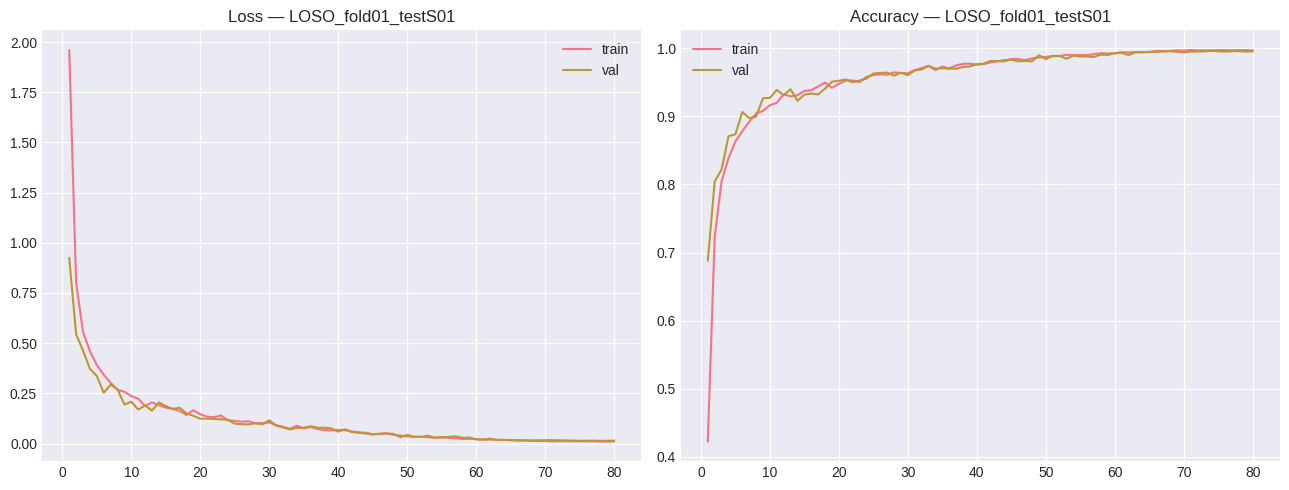

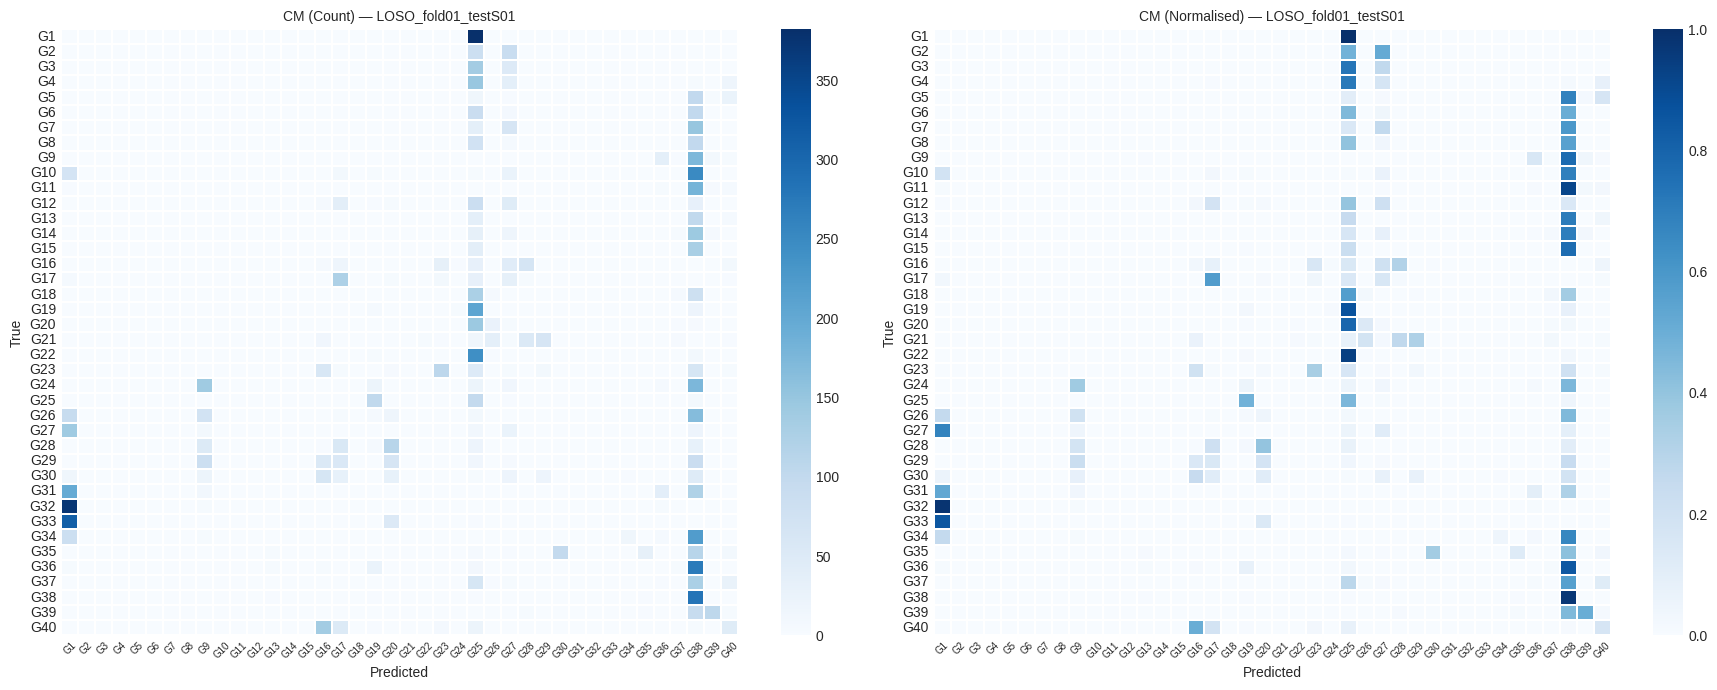

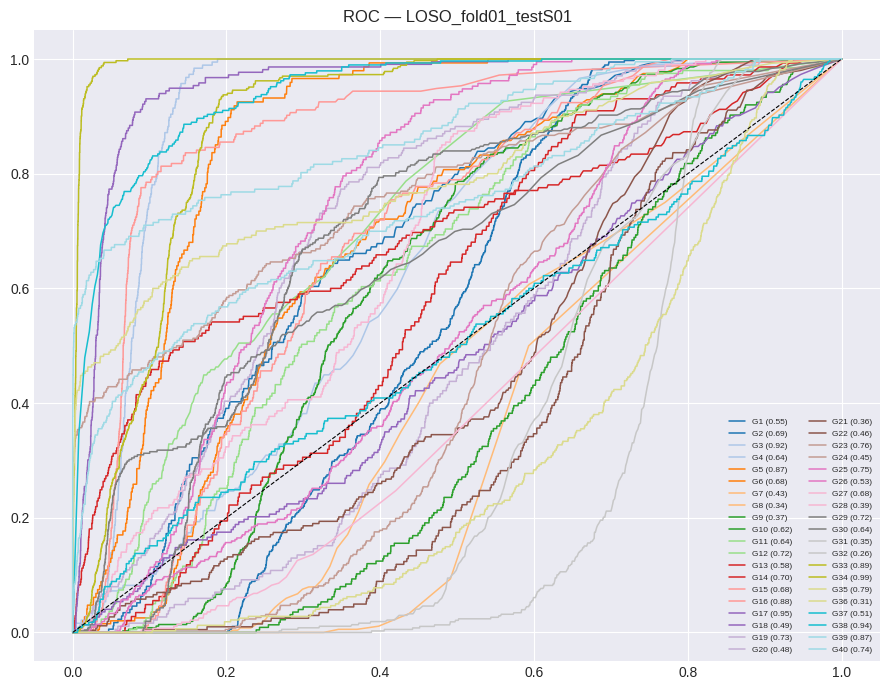

  acc=0.0834  f1=0.0584  auc=nan  train_wall=1320s
  [RAM] post-fold 1                     6.50 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB

  Fold 02/5  — test: Subject 02  | train: 4 subjects
  [RAM] pre-fold 2                      6.50 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB
  Fitting normaliser …
  DataLoaders — train 35,888  val 3,987  test 10,993  global batch 512  workers 4
  Model on cuda  (GPUs=2, params=518,296)
  [RAM] LOSO_fold02_testS02  ep=  5     6.73 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  10  tl=0.2670 ta=0.9078  vl=0.2539 va=0.9067
  [RAM] LOSO_fold02_testS02  ep= 10     6.95 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold02_testS02  ep= 15     7.17 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  20  tl=0.1611 ta=0.9432  vl=0.1880 va=0.9348
  [RAM] LOSO_fold02_testS02  ep= 20     7.40 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold02_testS02  ep= 25     7.63 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  

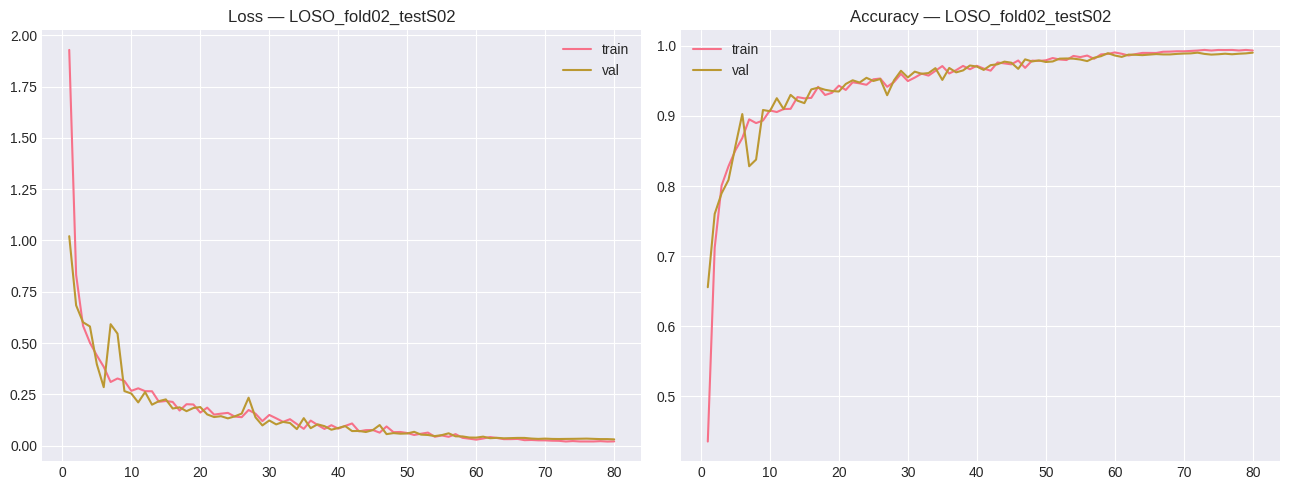

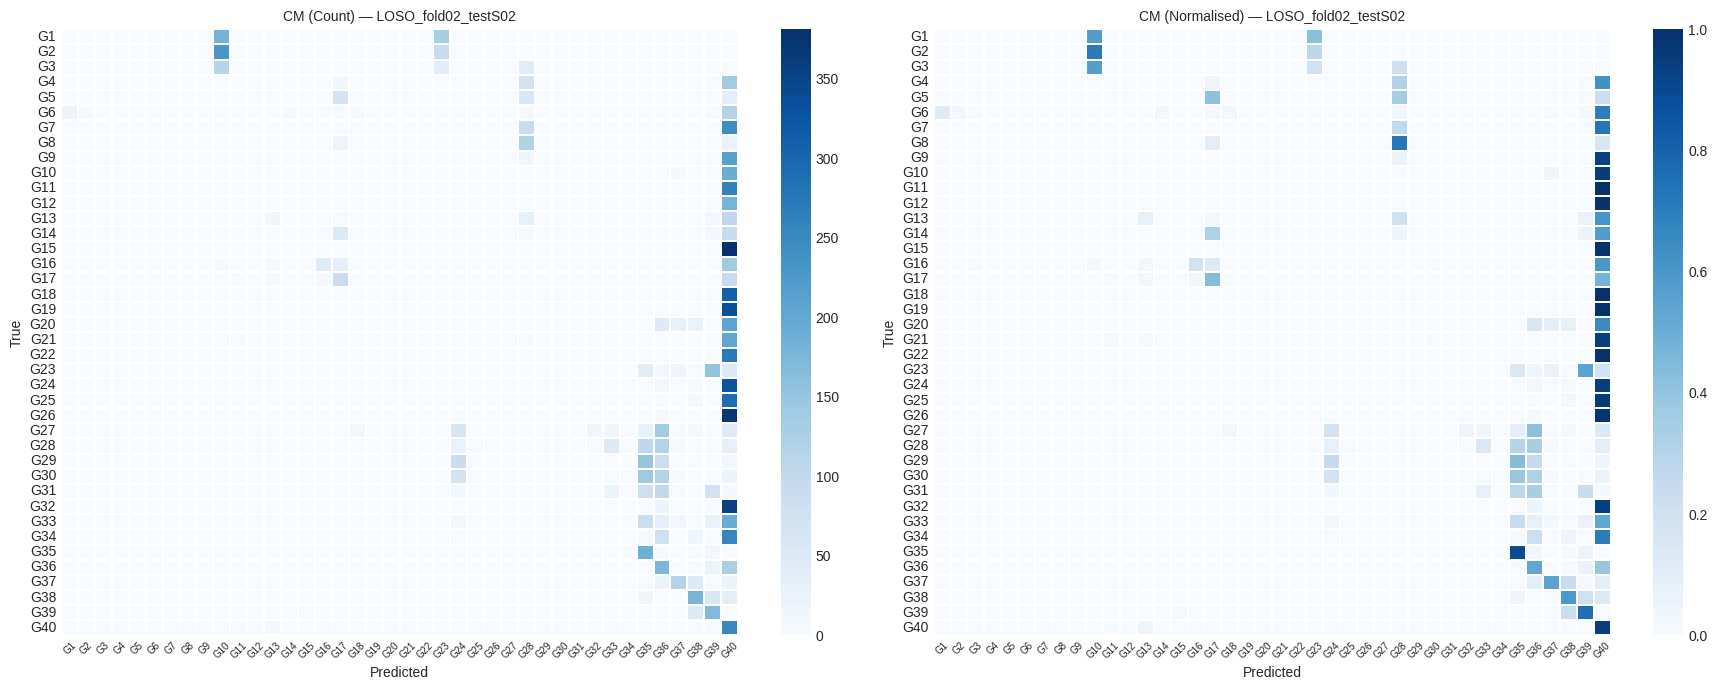

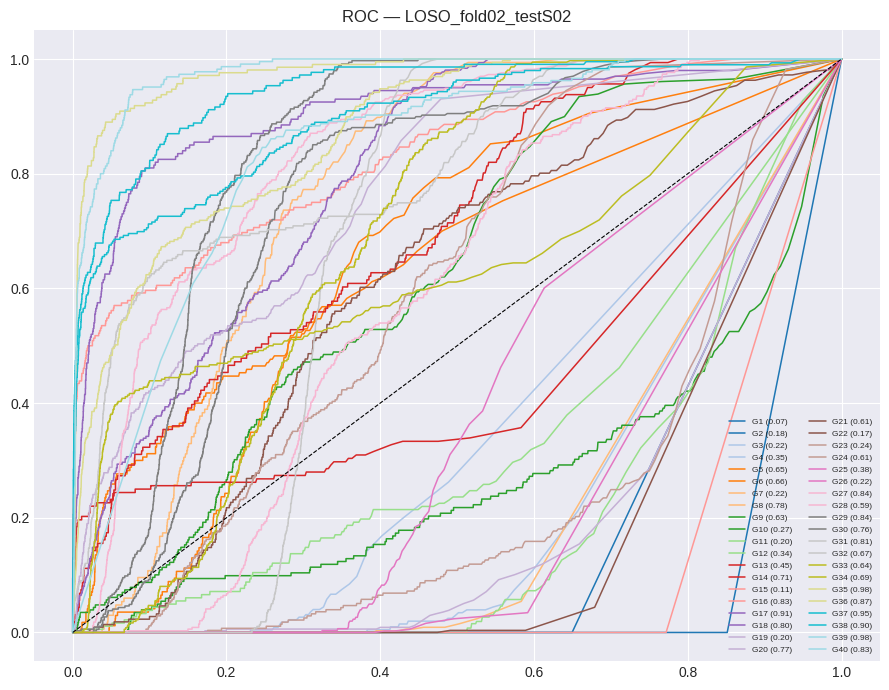

  acc=0.1117  f1=0.0667  auc=nan  train_wall=1293s
  [RAM] post-fold 2                     10.18 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB

  Fold 03/5  — test: Subject 03  | train: 4 subjects
  [RAM] pre-fold 3                      10.18 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB
  Fitting normaliser …
  DataLoaders — train 37,665  val 4,184  test 9,019  global batch 512  workers 4
  Model on cuda  (GPUs=2, params=518,296)
  [RAM] LOSO_fold03_testS03  ep=  5     10.41 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  10  tl=0.2443 ta=0.9131  vl=0.2011 va=0.9316
  [RAM] LOSO_fold03_testS03  ep= 10     10.65 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold03_testS03  ep= 15     10.88 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  20  tl=0.1425 ta=0.9495  vl=0.1465 va=0.9491
  [RAM] LOSO_fold03_testS03  ep= 20     11.12 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold03_testS03  ep= 25     11.36 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06

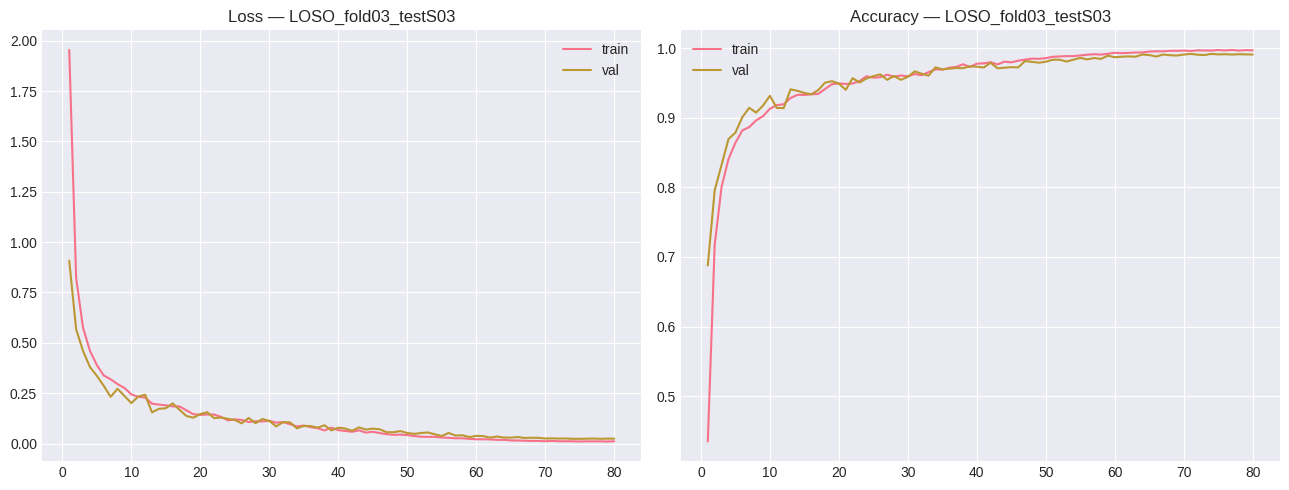

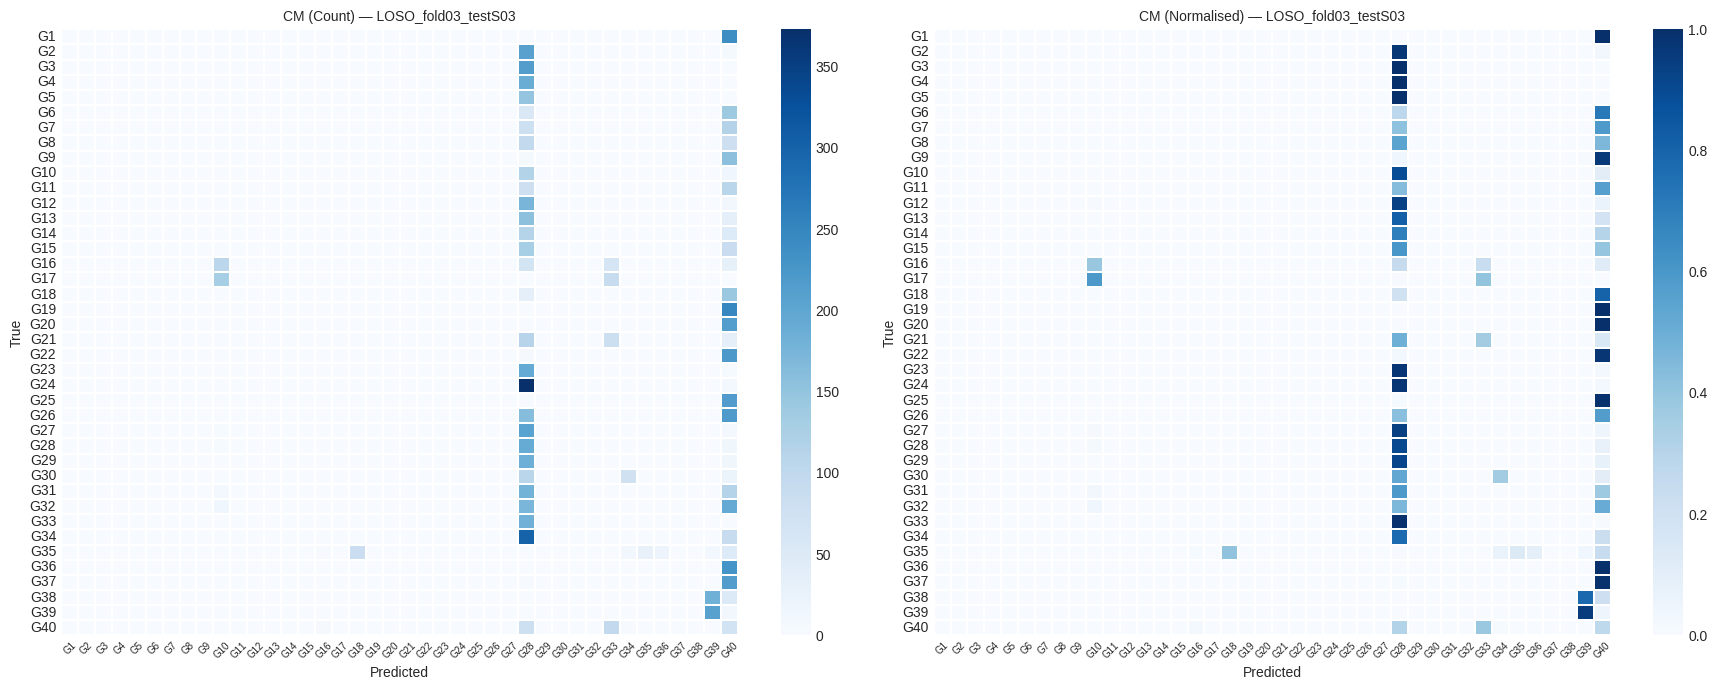

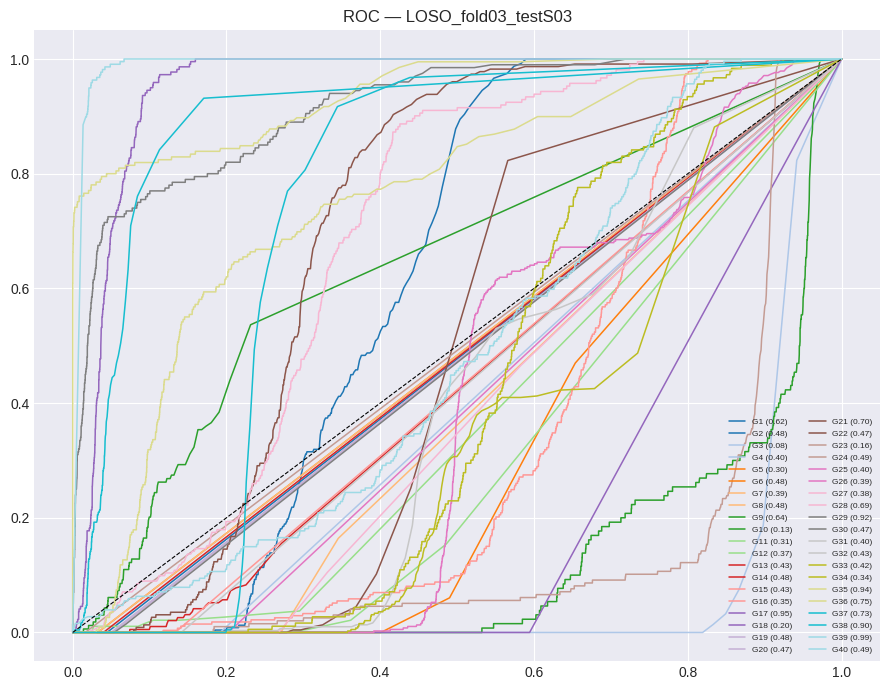

  acc=0.0551  f1=0.0247  auc=nan  train_wall=1415s
  [RAM] post-fold 3                     14.03 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB

  Fold 04/5  — test: Subject 04  | train: 4 subjects
  [RAM] pre-fold 4                      14.03 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB
  Fitting normaliser …
  DataLoaders — train 34,904  val 3,878  test 12,086  global batch 512  workers 4
  Model on cuda  (GPUs=2, params=518,296)
  [RAM] LOSO_fold04_testS04  ep=  5     14.24 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  10  tl=0.2587 ta=0.9091  vl=0.2502 va=0.9118
  [RAM] LOSO_fold04_testS04  ep= 10     14.46 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold04_testS04  ep= 15     14.68 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  20  tl=0.1427 ta=0.9506  vl=0.1756 va=0.9366
  [RAM] LOSO_fold04_testS04  ep= 20     14.90 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold04_testS04  ep= 25     15.12 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.0

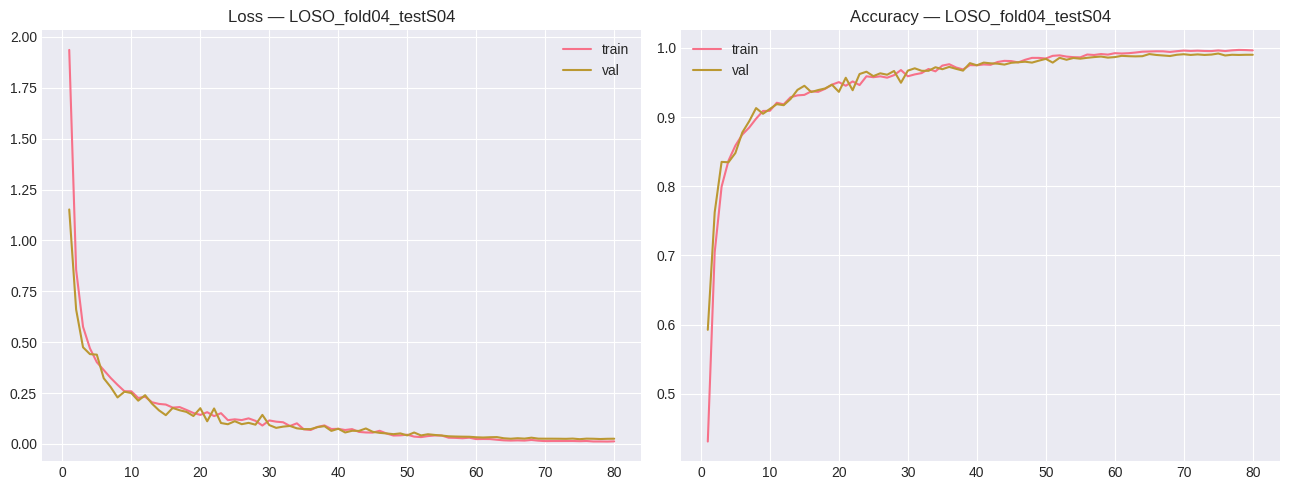

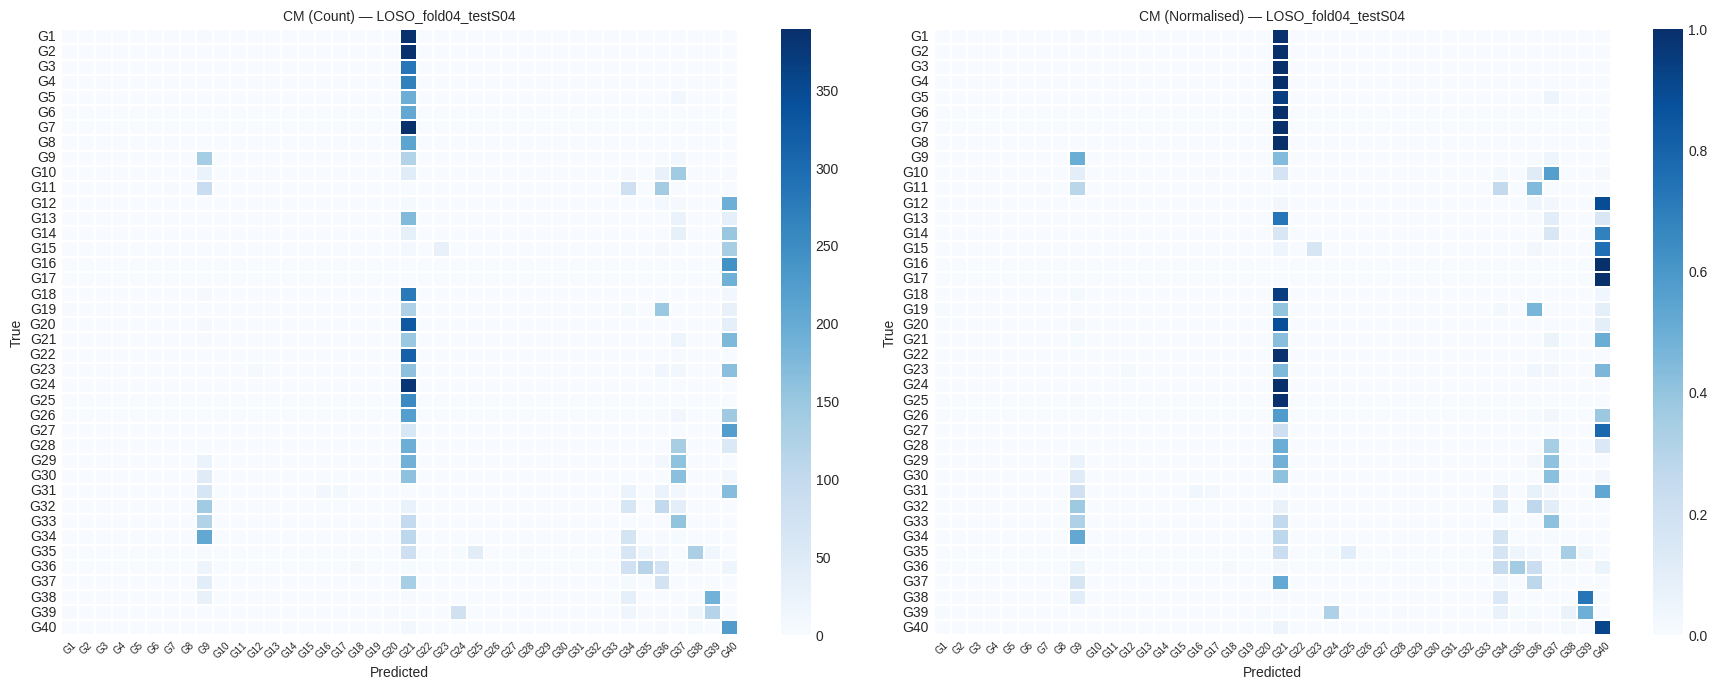

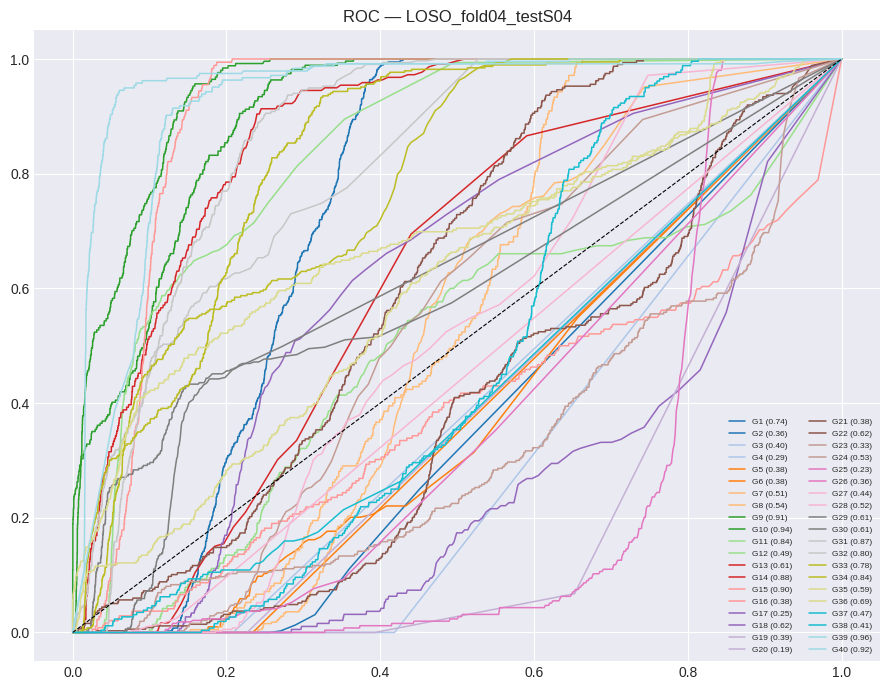

  acc=0.0654  f1=0.0298  auc=nan  train_wall=1299s
  [RAM] post-fold 4                     17.61 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB

  Fold 05/5  — test: Subject 05  | train: 4 subjects
  [RAM] pre-fold 5                      17.61 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB
  Fitting normaliser …
  DataLoaders — train 38,068  val 4,229  test 8,571  global batch 512  workers 4
  Model on cuda  (GPUs=2, params=518,296)
  [RAM] LOSO_fold05_testS05  ep=  5     17.86 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  10  tl=0.2347 ta=0.9175  vl=0.1866 va=0.9317
  [RAM] LOSO_fold05_testS05  ep= 10     18.09 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold05_testS05  ep= 15     18.33 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  ep  20  tl=0.1479 ta=0.9479  vl=0.1040 va=0.9626
  [RAM] LOSO_fold05_testS05  ep= 20     18.57 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06 GB
  [RAM] LOSO_fold05_testS05  ep= 25     18.81 GB  |  GPU0: 0.03/0.07 GB | GPU1: 0.02/0.06

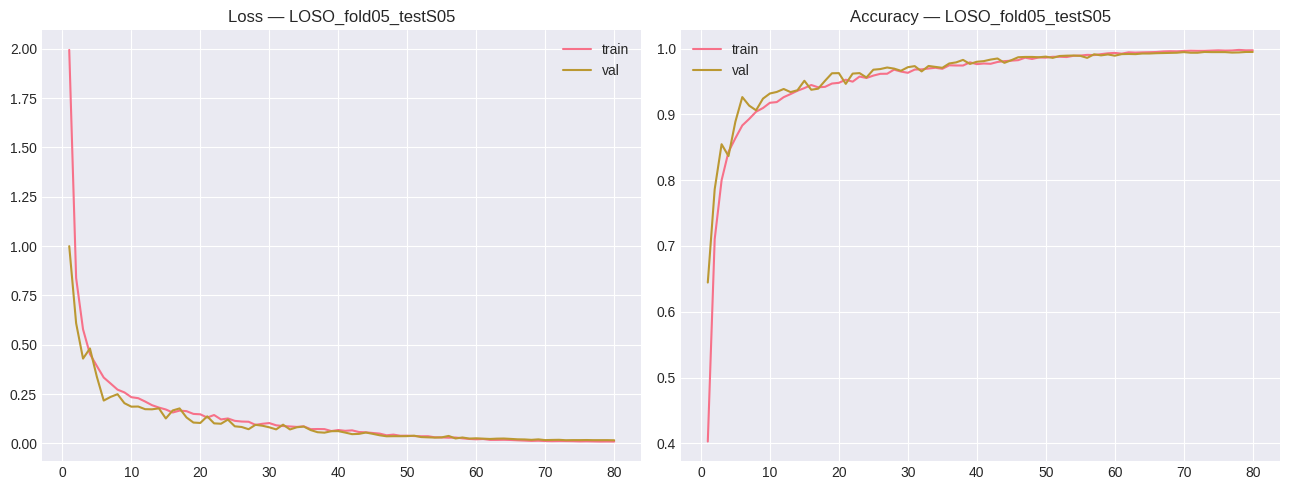

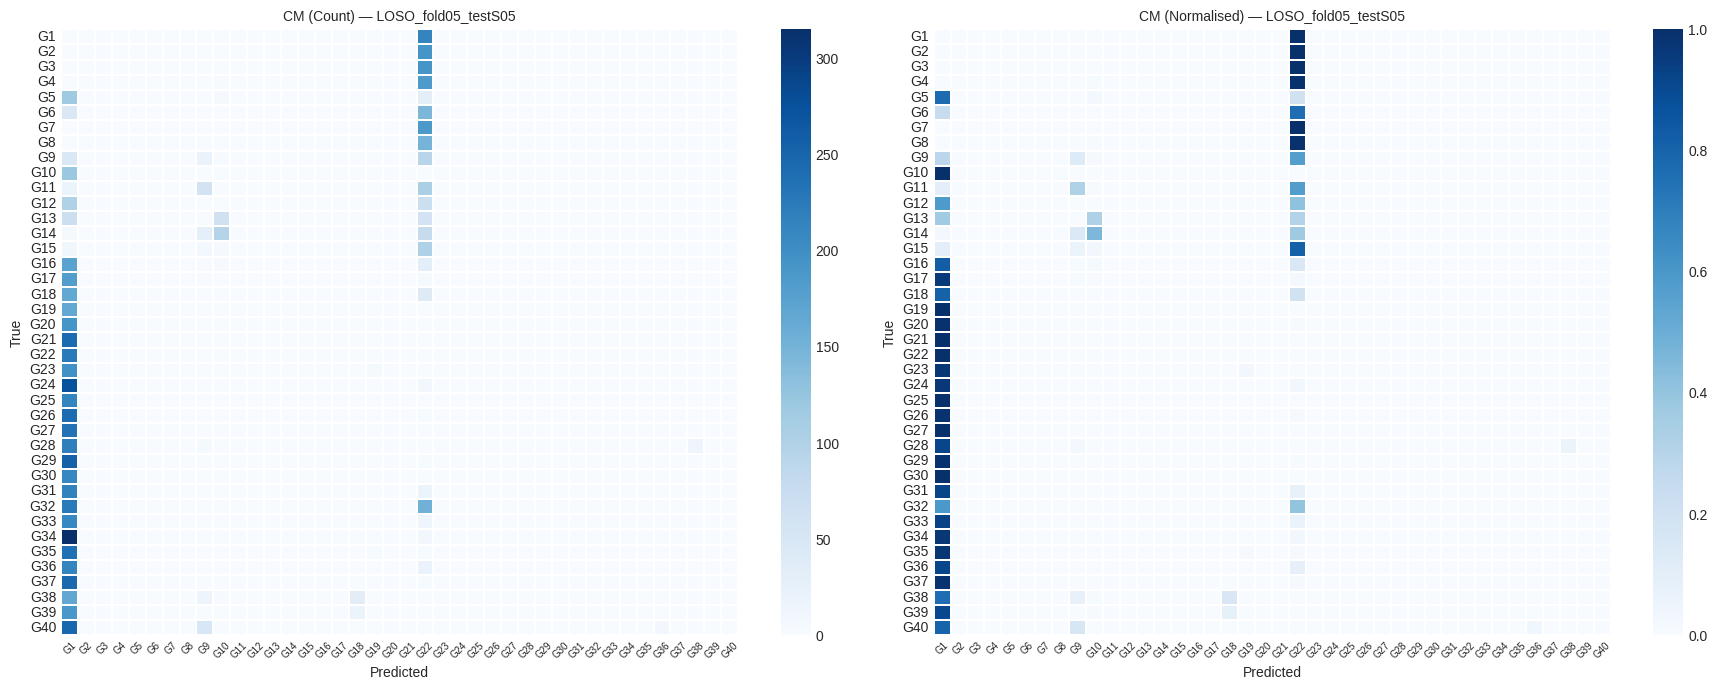

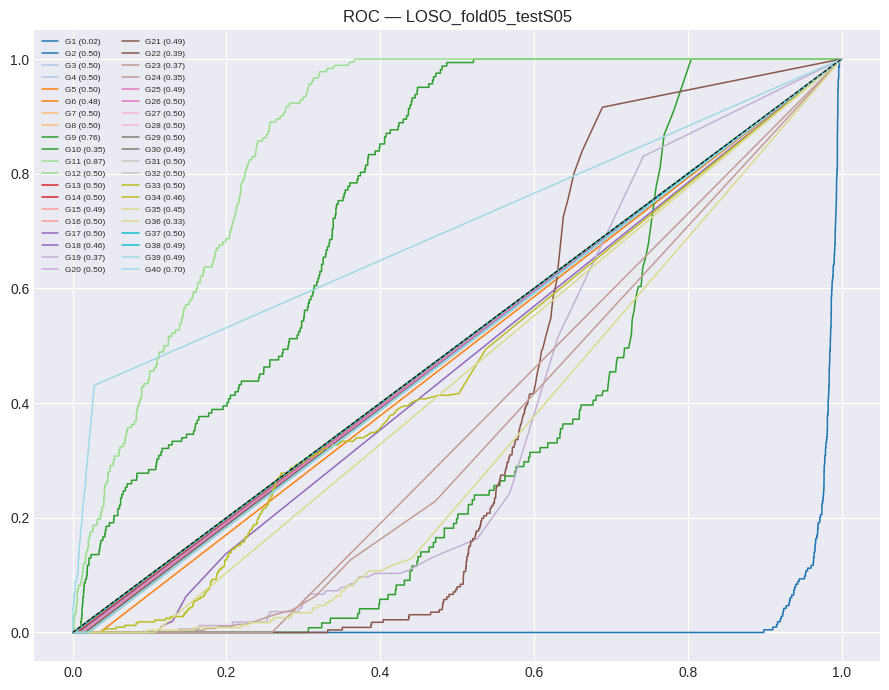

  acc=0.0025  f1=0.0022  auc=nan  train_wall=1433s
  [RAM] post-fold 5                     21.36 GB  |  GPU0: 0.02/0.06 GB | GPU1: 0.02/0.06 GB

  LOSO SUMMARY — MKA 1D CNN (2x GPU)

  Per-fold results:
  S01  acc=0.0834  f1=0.0584  auc=nan  train_wall=1320s
  S02  acc=0.1117  f1=0.0667  auc=nan  train_wall=1293s
  S03  acc=0.0551  f1=0.0247  auc=nan  train_wall=1415s
  S04  acc=0.0654  f1=0.0298  auc=nan  train_wall=1299s
  S05  acc=0.0025  f1=0.0022  auc=nan  train_wall=1433s

  Aggregate:
  accuracy       : 0.0636 ± 0.0361
  precision_w    : 0.0488 ± 0.0375
  recall_w       : 0.0636 ± 0.0361
  f1_w           : 0.0364 ± 0.0235
  roc_auc_w      : nan ± nan


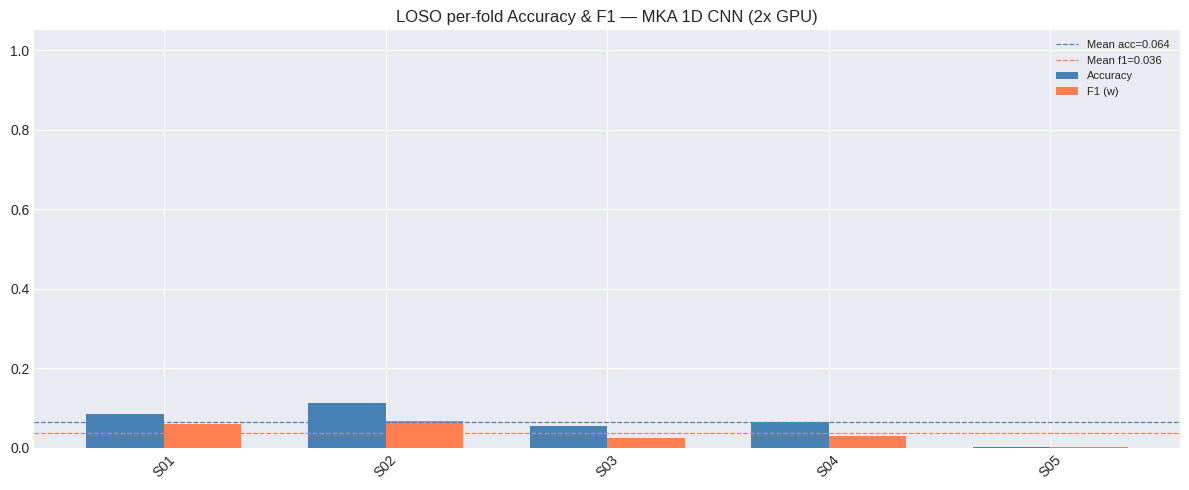


  Per-class mean accuracy (worst → best):
            G1  0.000  
            G2  0.000  
            G3  0.000  
            G4  0.000  
            G5  0.000  
            G6  0.000  
            G7  0.000  
            G8  0.000  
           G10  0.000  
           G11  0.000  
           G12  0.000  
           G14  0.000  
           G15  0.000  
           G18  0.000  
           G20  0.000  
           G22  0.000  
           G24  0.000  
           G26  0.000  
           G30  0.000  
           G31  0.000  
           G32  0.000  
           G29  0.001  
           G33  0.001  
           G19  0.006  
           G13  0.018  
           G27  0.023  
           G16  0.045  █
           G34  0.046  █
           G23  0.069  ██
           G21  0.085  ██
           G25  0.092  ██
           G37  0.110  ███
            G9  0.127  ███
           G36  0.152  ████
           G28  0.181  █████
           G17  0.204  ██████
           G35  0.241  ███████
           G38  0.314  █████████


In [15]:
# ════════════════════════════════════════════════════════════════════════════
#  Ultimate Hardware-Agnostic Execution Model
#  -----------------------------------------------------------------------
#  Auto-detects between Kaggle TPU v5e-8 and Dual GPU (CUDA) setups.
#  Dynamically routes memory flushing and execution logic.
# ════════════════════════════════════════════════════════════════════════════

# ── Auto-Detect Hardware ────────────────────────────────────────────────────
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    USE_TPU = True
    print("  [Hardware] Kaggle TPU v5e-8 detected via torch_xla.")
except ImportError:
    USE_TPU = False
    print(f"  [Hardware] CUDA/GPU detected. GPUs available: {torch.cuda.device_count() if torch.cuda.is_available() else 0}")
# ────────────────────────────────────────────────────────────────────────────

def main():
    ram_log = Config.RESULTS_DIR / 'ram_log.csv'
    ram_log.write_text('step,fold,epoch,ram_gb\n')

    # ════════════════════════════════════════════════════════════════════════
    # STEP 1  Cache all subjects (float16 .npy, mmap-ready)
    # ════════════════════════════════════════════════════════════════════════
    print('\n' + '='*72)
    print('  STEP 1 — Caching subjects  (float16 .npy, skip if cached)')
    print('='*72)

    loader = SubjectLoader()
    available_sids, n_channels = loader.process_all(Config.SUBJECTS)

    if not available_sids:
        raise RuntimeError('No subjects cached — check KAGGLE_INPUT path.')

    print(f'\n  Available: {len(available_sids)}/{len(Config.SUBJECTS)} subjects')
    print(f'  Channels : {n_channels}  (EMG + ACC)')
    ram_guard(label='after Step 1 (all subjects cached)', force=True)

    # ════════════════════════════════════════════════════════════════════════
    # STEP 2  Build a global LabelEncoder
    # ════════════════════════════════════════════════════════════════════════
    print('\n' + '='*72)
    print('  STEP 2 — Building global LabelEncoder')
    print('='*72)

    all_raw_labels = set()
    for sid in available_sids:
        m = json.loads((Config.CACHE_DIR / f's{sid:02d}_meta.json').read_text())
        all_raw_labels.update(m['unique_labels'])

    le          = LabelEncoder().fit(sorted(all_raw_labels))
    n_classes   = len(le.classes_)
    class_names = [f'G{g}' for g in le.classes_]
    print(f'  Classes : {n_classes}  → {class_names}')

    print('  Re-encoding label caches to 0-indexed …')
    for sid in tqdm(available_sids, desc='Re-encoding'):
        yp    = Config.CACHE_DIR / f's{sid:02d}_y.npy'
        y_raw = np.load(str(yp))
        y_enc = le.transform(y_raw.astype(np.int32)).astype(np.int16)
        np.save(str(yp), y_enc)
        del y_raw, y_enc
    del all_raw_labels
    gc.collect()
    print('  Done.')
    ram_guard(label='after Step 2 (labels re-encoded)', force=True)

    # ════════════════════════════════════════════════════════════════════════
    # STEP 3  LOSO (Hardware Auto-Routed)
    # ════════════════════════════════════════════════════════════════════════
    print('\n' + '='*72)
    if USE_TPU:
        print(f'  STEP 3 — {len(available_sids)}-fold LOSO  (TPU v5e-8, chip 0)')
    else:
        print(f'  STEP 3 — {len(available_sids)}-fold LOSO  ({Config.N_GPUS}x GPU)')
    print('='*72)

    all_metrics = []

    for fold_idx, test_sid in enumerate(available_sids):
        train_sids = [s for s in available_sids if s != test_sid]

        metrics = run_loso_fold(
            fold_idx    = fold_idx,
            test_sid    = test_sid,
            train_sids  = train_sids,
            n_channels  = n_channels,
            n_classes   = n_classes,
            class_names = class_names,
        )
        all_metrics.append(metrics)

        jpath  = Config.RESULTS_DIR / f'metrics_fold{fold_idx+1:02d}_S{test_sid:02d}.json'
        m_save = {k:v for k,v in metrics.items()
                  if k != 'per_class_acc' and not isinstance(v, np.ndarray)}
        jpath.write_text(json.dumps(m_save, indent=2))

        with open(ram_log, 'a') as f:
            f.write(f'post-fold,{fold_idx+1},done,{_ram_gb():.3f}\n')

        del metrics
        gc.collect()
        
        # ── Hardware-Specific VRAM/HBM Flushing ──
        if USE_TPU:
            xm.mark_step()
        elif torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ════════════════════════════════════════════════════════════════════════
    # STEP 4  Aggregate & save
    # ════════════════════════════════════════════════════════════════════════
    avgs, stds = summarise(all_metrics, class_names)

    rows     = [{k:v for k,v in m.items() if k!='per_class_acc'} for m in all_metrics]
    avg_row  = {k: avgs.get(k,'') for k in rows[0]}
    avg_row['split'] = 'LOSO_MEAN'
    std_row  = {k: stds.get(k,'') for k in rows[0]}
    std_row['split'] = 'LOSO_STD'

    df = pd.concat([pd.DataFrame(rows),
                    pd.DataFrame([avg_row]),
                    pd.DataFrame([std_row])], ignore_index=True)
    csv_path = Config.RESULTS_DIR / 'summary_loso.csv'
    df.to_csv(csv_path, index=False)

    print(f'\n  Summary CSV → {csv_path}')
    print(f'  Plots       → {Config.PLOT_DIR}')
    print(f'  Models      → {Config.CKPT_DIR}')
    print(f'  RAM log     → {ram_log}')
    print(f'\n  LOSO Mean Accuracy : {avgs["accuracy"]:.4f} ± {stds["accuracy"]:.4f}')
    print(f'  LOSO Mean F1 (W)   : {avgs["f1_w"]:.4f} ± {stds["f1_w"]:.4f}')
    print(f'  LOSO Mean ROC-AUC  : {avgs["roc_auc_w"]:.4f} ± {stds["roc_auc_w"]:.4f}')
    ram_guard(label='final', force=True)
    print('\n  Done. Use LOSO Mean F1 as the reference baseline.\n')

if __name__ == "__main__":
    main()